In [20]:
using LinearAlgebra

In [21]:
function hat(v)
    return [0 -v[3] v[2];
            v[3] 0 -v[1];
            -v[2] v[1] 0]
end

H = [zeros(1,3); I];
T = [1  zeros(1,3);
     zeros(3,1) -I];

function L(q)
    return [q[1]          -q[2:4]';
            q[2:4]    q[1]*I + hat(q[2:4])]
end

function R(q)
    return [q[1]          -q[2:4]';
            q[2:4]    q[1]*I - hat(q[2:4])]
end

function G(q)
    return L(q)*H
end

function Q(q)
    return H'*L(q)*R(q)'*H
end

Q (generic function with 1 method)

In [22]:
#dynamics
function dynamics(x)
    q = x[1:4]
    ω = x[5:7]
    
    q̇ = 0.5*G(q)*ω
    ω̇ = -J\(hat(ω)*J*ω)

    ẋ = [q̇; ω̇]
end

dynamics (generic function with 1 method)

In [23]:
#Classic RK4 integrator: https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods
function rkstep(x)
    f1 = dynamics(x)
    f2 = dynamics(x + 0.5*h*f1)
    f3 = dynamics(x + 0.5*h*f2)
    f4 = dynamics(x + h*f3)
    xn = x + (h/6.0)*(f1 + 2*f2 + 2*f3 + f4)
    xn[1:4] .= xn[1:4]/norm(xn[1:4]) #re-normalize quaternion
    return xn
end

rkstep (generic function with 1 method)

In [24]:
J = Diagonal([1.0; 2; 3])

3×3 Diagonal{Float64, Vector{Float64}}:
 1.0   ⋅    ⋅ 
  ⋅   2.0   ⋅ 
  ⋅    ⋅   3.0

In [25]:
h = 0.1 #time step
n = 1000 #number of time steps
tf = n*h #final time

#sample random angular velocity
q0 = [1; 0; 0; 0]
#ω0 = randn(3)
ω0 = [0; 1; 0] + 0.1*randn(3);
x0 = [q0; ω0];

In [26]:
#Simulate n time steps
xhist = zeros(7,n)
xhist[:,1] .= x0
for k = 1:(n-1)
    xhist[:,k+1] = rkstep(xhist[:,k])
end

In [27]:
# import Pkg
# Pkg.add(["MeshCat", "GeometryBasics", "CoordinateTransformations", "Rotations"])

In [28]:
using MeshCat, GeometryBasics, CoordinateTransformations, Rotations

In [29]:
vis = Visualizer()

┌ Info: Listening on: 127.0.0.1:8700, thread id: 1
└ @ HTTP.Servers C:\Users\Tim\.julia\packages\HTTP\ShTJs\src\Servers.jl:382
┌ Info: MeshCat server started. You can open the visualizer by visiting the following URL in your browser:
│ http://127.0.0.1:8700
└ @ MeshCat C:\Users\Tim\.julia\packages\MeshCat\4DqVC\src\visualizer.jl:39


MeshCat Visualizer with path /meshcat at http://127.0.0.1:8700

In [30]:
render(vis)

MeshCat.DisplayedVisualizer(MeshCat.CoreVisualizer(MeshCat.SceneTrees.SceneNode(nothing, nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}()), Set{HTTP.WebSockets.WebSocket}(), ip"127.0.0.1", 8700, HTTP.Servers.Server{HTTP.Servers.Listener{Nothing, Sockets.TCPServer}}(HTTP.Servers.Listener{Nothing, Sockets.TCPServer}(Sockets.InetAddr{Sockets.IPv4}(ip"127.0.0.1", 8700), "127.0.0.1", "8700", nothing, Sockets.TCPServer(Base.Libc.WindowsRawSocket(0x0000000000003994) active)), nothing, Set{HTTP.Connections.Connection}(), Task (runnable) @0x0000012584b9b650, ReentrantLock(nothing, 0x00000000, 0x00, Base.GenericCondition{Base.Threads.SpinLock}(Base.IntrusiveLinkedList{Task}(nothing, nothing), Base.Threads.SpinLock(0)), (62, -1, 0))), MeshCat.AnimationContext[]))

In [31]:
setobject!(vis[:box1], Rect(Vec(-0.3, -0.2, -0.1), Vec(0.6, 0.4, 0.2)))

MeshCat Visualizer with path /meshcat/box1 at http://127.0.0.1:8700

In [32]:
anim = Animation(vis)

for t = 1:n
    atframe(anim, t) do
        settransform!(vis[:box1], LinearMap(QuatRotation(xhist[1,t], xhist[2,t], xhist[3,t], xhist[4,t])))
    end
end

setanimation!(vis, anim)

In [33]:
hn = zeros(3,n)
T = zeros(n)
for k = 1:n
    T[k] = 0.5*xhist[5:7,k]'*J*xhist[5:7,k]
    hn[:,k] .= Q(xhist[1:4,k])*(J*xhist[5:7,k])
end

In [34]:
using PythonPlot
plot(T)

ArgumentError: ArgumentError: Package PythonPlot not found in current path.
- Run `import Pkg; Pkg.add("PythonPlot")` to install the PythonPlot package.

In [35]:
plot(hn[1,:])
plot(hn[2,:])
plot(hn[3,:])

UndefVarError: UndefVarError: `plot` not defined

In [36]:
#Draw momentum sphere
# Make data
u = range(-π, π; length = 100)
v = range(0, π; length = 100)
x = cos.(u)*sin.(v)'
y = sin.(u)*sin.(v)'
z = ones(size(u))*cos.(v)';
import Plots as plt
plt.plotlyjs()
plt.surface(x, y, z, color=:darkcyan, colorbar=false);
plt.scatter!([1.03; 0; -1.03; 0],[0; 0; 0; 0],[0; 1.03; 0; -1.03], markercolor = :greenyellow, legend=false)
plt.scatter!([0; 0],[1.03; -1.03],[0; 0], markercolor = :red, legend=false);

ArgumentError: ArgumentError: Package PlotlyJS not found in current path.
- Run `import Pkg; Pkg.add("PlotlyJS")` to install the PlotlyJS package.

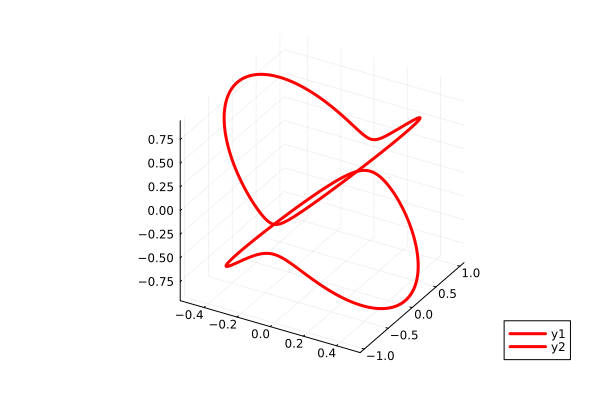

In [37]:
#Plot normalized momentum trajectory from sim data
hhist = zeros(3,n)
for k = 1:n
    hhist[:,k] .= 1.03*(J*xhist[5:7,k])/norm(J*xhist[5:7,k])
end
plt.plot3d!(hhist[1,:],hhist[2,:],hhist[3,:],color=:red,linewidth=3)